# Bayesian Analysis

In [1]:
from preprocessing.pipeline import preprocess_all

from frequentist.models import fit_arima_model, forecast_arima_model, expanding_window_forecast_arima

import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

## Preprocess

In [2]:
artifacts = preprocess_all(
    data_path="../data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],   # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],         # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags= False,
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]

target_col = "log_eui"


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

## ARIMA(2,0,1) vs AR(3)

## ARIMA(2,0,1)

In [3]:
# ===========================================
# Run ARIMA for ONE SET of PARAMETERS (p,d,q)
# ===========================================

y_train_arima = train_df[target_col]
y_test_arima = test_df[target_col]

# Choose the ARIMA order manually
order = (2, 0, 1)      # <-- put your numbers here
seasonal_order = (0, 0, 0, 0)

print(f"\n=== Fitting ARIMA{order} on {target_col} ===")

# ---- Fit model ----
res = fit_arima_model(
    y=y_train_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)


=== Fitting ARIMA(2, 0, 1) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



### Residuals

In [4]:
arima_201_resid_in = res.resid.dropna()

arima_201_resid_in.name = "arima_201_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_201_resid_in.head())

arima_201_model = res


Best ARIMA — in-sample residuals (head):
date
1996-01-01   -0.867753
1996-02-01   -0.131574
1996-03-01   -0.687801
1996-04-01    0.002753
1996-05-01    0.750437
Name: arima_201_resid_in, dtype: float64


### Forecasts

In [5]:
# ===========================================
# 1-step-ahead EXPANDING-WINDOW forecasts
# ===========================================

print("\n=== 1-step-ahead expanding-window forecasts on TEST sample ===")

arima_201_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)


=== 1-step-ahead expanding-window forecasts on TEST sample ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe


### ---- OOS errors ----

In [6]:
arima_201_errors_oos = (y_test_arima - arima_201_forecast).dropna()
arima_201_errors_oos.name = "arima_201_errors_oos"

rmse = float(np.sqrt(np.mean(arima_201_errors_oos**2)))
print("\nRMSE (1-step expanding window):", rmse)

print("\nHEAD of 1-step expanding-window forecast errors:")
print(arima_201_errors_oos.head())


RMSE (1-step expanding window): 0.2710188867275635

HEAD of 1-step expanding-window forecast errors:
date
2018-05-01   -0.054371
2018-06-01    0.239644
2018-07-01    0.182712
2018-08-01    0.076472
2018-09-01   -0.000189
Name: arima_201_errors_oos, dtype: float64


## Bayesian AR(3)

In [7]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, pacf
import warnings
warnings.filterwarnings("ignore")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [8]:
# Checks for informed prior choice

y_train_ar = train_df[target_col]
y_test_ar  = test_df[target_col]
y_train_np = y_train_ar.values.astype(float)

# Compute the values from ARIMA(3,0,0) for informed priors
arima_300_model = fit_arima_model(
    y=y_train_arima,
    order=(3, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# Choose phi1 and phi2 with the PACF value at lag 1 (frequentist_original)
pacf_vals = pacf(y_train_ar, nlags=3)
informed_phi1 = pacf_vals[1]
informed_phi2 = pacf_vals[2]
informed_phi3 = pacf_vals[3]

# Check the Standard Deviation of ARIMA and use it as sigma
informed_sigma_scale = arima_300_model.resid.std()

# Prior Predictive Check involves simulating data using only your priors, before looking at the actual observations.
# use pm.sample_prior_predictive()

# Check the long-term trend for c
informed_c_mean = y_train_ar.mean()

# This represents the Frequentist uncertainty about phis
informed_phi1_sigma = arima_300_model.bse["ar.L1"]
informed_phi2_sigma = arima_300_model.bse["ar.L2"]
informed_phi3_sigma = arima_300_model.bse["ar.L3"]

print(f"Informed c (mean): {informed_c_mean:.4f}")
print(f"Informed phi1 (mu): {informed_phi1:.4f}, phi2 (mu): {informed_phi2:.4f}")
print(f"Informed sigma (scale): {informed_sigma_scale:.4f}")
print(f"Informed phi1 sigma (uncertainty): {informed_phi1_sigma:.4f}")
print(f"Informed phi2 sigma (uncertainty): {informed_phi2_sigma:.4f}")
print(f"Informed phi3 sigma (uncertainty): {informed_phi3_sigma:.4f}")

Informed c (mean): -0.2076
Informed phi1 (mu): 0.6856, phi2 (mu): 0.3044
Informed sigma (scale): 0.5128
Informed phi1 sigma (uncertainty): 0.0310
Informed phi2 sigma (uncertainty): 0.0415
Informed phi3 sigma (uncertainty): 0.0353


In [9]:
with pm.Model() as informed_ar3_model:
    # --- Informed Priors ---
    c     = pm.Normal("c",     mu=informed_c_mean,   sigma=0.5)
    phi1  = pm.Normal("phi1",  mu=informed_phi1,     sigma=informed_phi1_sigma)
    phi2  = pm.Normal("phi2",  mu=informed_phi2,     sigma=informed_phi2_sigma)
    phi3  = pm.Normal("phi3",  mu=informed_phi3,     sigma=informed_phi3_sigma)
    sigma = pm.HalfNormal("sigma", sigma=informed_sigma_scale)

    # Degrees of freedom (nu) for tail behavior
    # Large nu = Normal tails; Small nu = Fat tails.
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    # --- Likelihood (Model Structure) ---
    # We define the likelihood so the prior predictive check can simulate observations.
    mu = c + phi1 * y_train_np[2:-1] + phi2 * y_train_np[1:-2] + phi3 * y_train_np[0:-3]
    obs = pm.StudentT("obs", nu=nu, mu=mu, sigma=sigma, observed=y_train_np[3:])


Sampling: [c, nu, obs, phi1, phi2, phi3, sigma]


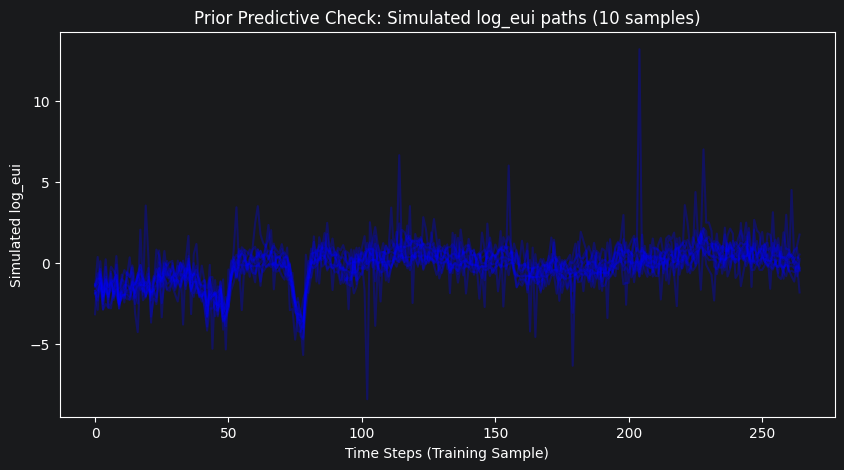

In [10]:
# --- 4. Prior Predictive Check ---
with informed_ar3_model:
    prior_pc = pm.sample_prior_predictive(samples=500, random_seed=6)

plt.figure(figsize=(10, 5))

# Plot the simulated 'obs' data from the priors
# This allows you to check if the range of log_eui stays physically plausible.
for i in range(10):
    plt.plot(prior_pc.prior_predictive["obs"][0, i, :], color="blue", alpha=0.3)

plt.title("Prior Predictive Check: Simulated log_eui paths (10 samples)")
plt.xlabel("Time Steps (Training Sample)")
plt.ylabel("Simulated log_eui")
plt.show()

now we implement the MCMC

In [11]:
with informed_ar3_model:
    # We use NUTS sampling to explore the posterior distribution
    idata_informed = pm.sample(
        draws=1000,
        tune=500,
        chains=4,
        target_accept=0.9,
        random_seed=6,
        progressbar=True
    )

# --- Extract posterior draws for future cells ---
post_inf = idata_informed.posterior
c_draws    = post_inf["c"].values.flatten()
phi1_draws = post_inf["phi1"].values.flatten()
phi2_draws = post_inf["phi2"].values.flatten()
phi3_draws = post_inf["phi3"].values.flatten()
sigma_draws = post_inf["sigma"].values.flatten()

print("Informed model sampling complete and draws extracted.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma, nu]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 916 seconds.


Informed model sampling complete and draws extracted.


Convergence Diagnostics
You must check if the NUTS sampler actually converged on a stable solution. If the chains didn't "mix" well, your forecasts will be unreliable.
1. R-hat ($\hat{R}$): Should be extremely close to 1.00.
2. ESS (Effective Sample Size): Should ideally be $> 400$ per chain to ensure you have enough independent samples.
3. Trace Plots: You want to see "fuzzy caterpillars," not distinct lines or trends.

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
c      0.007  0.016  -0.023    0.036        0.0      0.0    4852.0    2588.0   
phi1   0.595  0.026   0.551    0.646        0.0      0.0    5115.0    3352.0   
phi2   0.173  0.032   0.118    0.238        0.0      0.0    4305.0    2972.0   
phi3   0.217  0.030   0.161    0.273        0.0      0.0    4418.0    2854.0   
sigma  0.193  0.018   0.161    0.229        0.0      0.0    4064.0    2733.0   

       r_hat  
c        1.0  
phi1     1.0  
phi2     1.0  
phi3     1.0  
sigma    1.0  


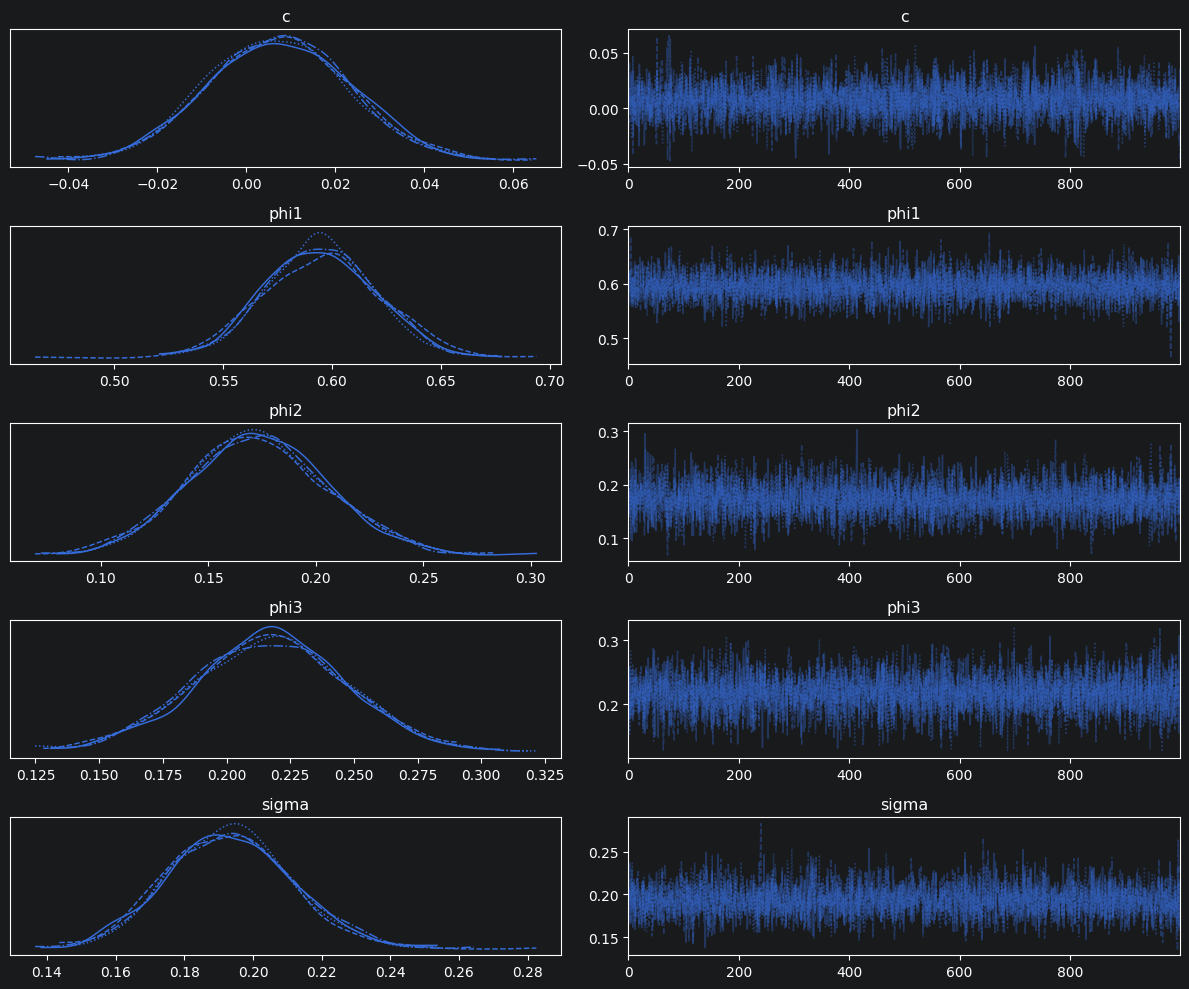

In [12]:
# Check the numbers
print(az.summary(idata_informed, var_names=["c", "phi1", "phi2", "phi3", "sigma"]))

# Check the visuals
az.plot_trace(idata_informed, var_names=["c", "phi1", "phi2", "phi3", "sigma"])
plt.tight_layout()
plt.show()

Sampling: [obs]


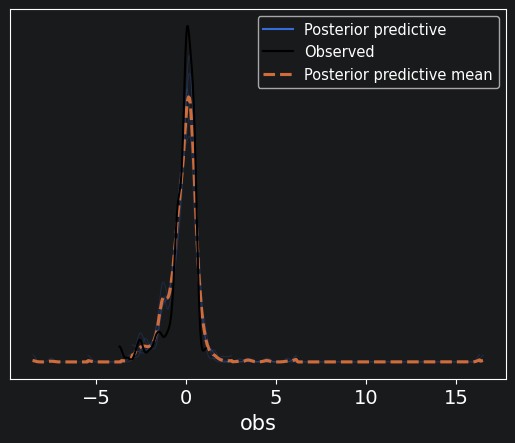

In [13]:
with informed_ar3_model:
    # Generate data from the POSTERIOR
    ppc = pm.sample_posterior_predictive(idata_informed)

# Plot the real data vs. the model's version
az.plot_ppc(ppc, num_pp_samples=5)
plt.show()

In [14]:
# 1. Calculate point estimates (Posterior Means)
c_pm     = float(post_inf["c"].values.mean())
phi1_pm  = float(post_inf["phi1"].values.mean())
phi2_pm  = float(post_inf["phi2"].values.mean())
phi3_pm  = float(post_inf["phi3"].values.mean())
sigma_pm = float(post_inf["sigma"].values.mean())

mu_in = (c_pm +
         phi1_pm * y_train_np[2:-1] +
         phi2_pm * y_train_np[1:-2] +
         phi3_pm * y_train_np[0:-3])

# 3. Calculate residuals (Actual - Predicted)
# We align with the target starting at index 3
resid_in = y_train_np[3:] - mu_in

# 4. Diagnostics: Ljung-Box check
lb_results = acorr_ljungbox(resid_in, lags=[1, 2, 3, 12, 24, 36], return_df=True)
print("Ljung-Box Test on AR(3) Residuals:")
print(lb_results)

Ljung-Box Test on AR(3) Residuals:
       lb_stat     lb_pvalue
1     5.661152  1.734472e-02
2     5.778838  5.560851e-02
3    10.819004  1.274595e-02
12   90.489256  3.969636e-14
24  107.918797  1.299806e-12
36  160.825906  1.042212e-17


### Expanding window

In [15]:
# ---- Configuration for Speed ----
REFIT_EVERY = 6  # Only run NUTS every N months
EW_DRAWS    = 200 # Reduced draws for speed during the loop
EW_TUNE     = 100  # Reduced tuning steps
EW_CHAINS   = 4

# Prepare data arrays
y_full_np     = artifacts["features_df"][target_col].values.astype(float)
train_end_loc = artifacts["features_df"].index.get_loc(y_train_ar.index[-1])
n_test_ew     = len(y_test_ar)

# Output containers
ew_point  = np.full(n_test_ew, np.nan)
ew_hdi_lo = np.full(n_test_ew, np.nan)
ew_hdi_hi = np.full(n_test_ew, np.nan)

# Initialize with your "Informed" draws from the first sampler
_c_draws, _phi1_draws, _phi2_draws, _phi3_draws = c_draws, phi1_draws, phi2_draws, phi3_draws

print(f"Running {n_test_ew} steps (Refitting every {REFIT_EVERY} months)...")

for step in range(n_test_ew):
    # Current window ends at the day before the forecast target
    win_end = train_end_loc + step + 1
    y_win   = y_full_np[:win_end]

    # 1. Periodic Refit: Update the parameters with the new data
    if step % REFIT_EVERY == 0 and step > 0:
        with pm.Model() as _ew_model:
            # Use current posterior means as the center for new priors (Informed Warm-start)
            c_e  = pm.Normal("c",    mu=_c_draws.mean(),    sigma=0.3)
            p1   = pm.Normal("phi1", mu=_phi1_draws.mean(), sigma=0.1)
            p2   = pm.Normal("phi2", mu=_phi2_draws.mean(), sigma=0.1)
            p3   = pm.Normal("phi3", mu=_phi3_draws.mean(), sigma=0.1)
            s_e  = pm.HalfNormal("sigma", sigma=informed_sigma_scale)

            # Likelihood for AR(3)
            mu_win = c_e + p1*y_win[2:-1] + p2*y_win[1:-2] + p3*y_win[0:-3]
            pm.Normal("obs", mu=mu_win, sigma=s_e, observed=y_win[3:])

            # Fast sampling
            _trace = pm.sample(draws=EW_DRAWS, tune=EW_TUNE, chains=EW_CHAINS,
                               progressbar=False, random_seed=step)

            # Update the draws for the next steps
            _c_draws    = _trace.posterior["c"].values.flatten()
            _phi1_draws = _trace.posterior["phi1"].values.flatten()
            _phi2_draws = _trace.posterior["phi2"].values.flatten()
            _phi3_draws = _trace.posterior["phi3"].values.flatten()

        print(f"  [Refit] Month {step+1}/{n_test_ew} complete.")

    # 2. 1-Step Ahead Forecast
    # Use the most recent posterior draws to predict the next point
    # y[t] = c + phi1*y[t-1] + phi2*y[t-2] + phi3*y[t-3]
    mu_step = (_c_draws +
               _phi1_draws * y_win[-1] +
               _phi2_draws * y_win[-2] +
               _phi3_draws * y_win[-3])

    hdi = az.hdi(mu_step, hdi_prob=0.94)
    ew_point[step]  = mu_step.mean()
    ew_hdi_lo[step] = hdi[0]
    ew_hdi_hi[step] = hdi[1]

# Wrap results in Series
ar3_bayes_ew_forecast = pd.Series(ew_point, index=y_test_ar.index, name="Bayes_AR3_EW")
print("\nExpanding window calculation complete.")

Running 67 steps (Refitting every 6 months)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 97 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


  [Refit] Month 7/67 complete.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 100 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


  [Refit] Month 13/67 complete.


...

  [Refit] Month 55/67 complete.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 111 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


  [Refit] Month 61/67 complete.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 118 seconds.


  [Refit] Month 67/67 complete.

Expanding window calculation complete.


## Comparison

In [16]:
def compute_metrics(y_true, y_pred, label):
    err = (y_true - y_pred).dropna()
    return {
        "Model": label,
        "RMSE":  np.sqrt(np.mean(err**2)),
        "MAE":   np.mean(np.abs(err)),
        "Bias":  np.mean(err), # Positive = Under-predicting, Negative = Over-predicting
        "Var(Error)": np.var(err)
    }

# Ensure you are comparing the Expanding Window results
# Note: Align lengths if they differ due to lags
comparison_rows = [
    compute_metrics(np.exp(y_test_arima), np.exp(arima_201_forecast), "Freq ARIMA(2,0,1)"),
    compute_metrics(np.exp(y_test_ar), np.exp(ar3_bayes_ew_forecast), "Bayes AR(3)")
]

df_cmp = pd.DataFrame(comparison_rows).set_index("Model")
print("=== Point Forecast Quality Comparison ===")
print(df_cmp.round(6))

=== Point Forecast Quality Comparison ===
                       RMSE       MAE      Bias  Var(Error)
Model                                                      
Freq ARIMA(2,0,1)  0.350329  0.235728  0.083337    0.115785
Bayes AR(3)        0.352946  0.240915  0.071528    0.119455


Residual Adequacy (Ljung-Box Comparison)
A model is only "high quality" if its residuals are white noise.

In [17]:
# Compare Ljung-Box p-values side-by-side
# We want these to be ABOVE 0.05
lb_freq = acorr_ljungbox(arima_201_model.resid.dropna(), lags=[6, 12], return_df=True)
lb_bay  = acorr_ljungbox(resid_in, lags=[6, 12], return_df=True)

print("\n=== Residual Quality (p-values) ===")
print(f"Freq ARIMA(6): {lb_freq['lb_pvalue'].values}")
print(f"Bayes AR(3) (6): {lb_bay['lb_pvalue'].values}")


=== Residual Quality (p-values) ===
Freq ARIMA(6): [3.43124510e-10 3.93628604e-14]
Bayes AR(3) (6): [4.76528285e-10 3.96963607e-14]


Visual Comparison & Uncertainty Bands
This plot reveals if the Bayesian model is "honest" about its mistakes. Frequentist bands (Confidence Intervals) are often fixed-width, while Bayesian Credible Intervals (HDI) can expand when the model is genuinely confused by the data.

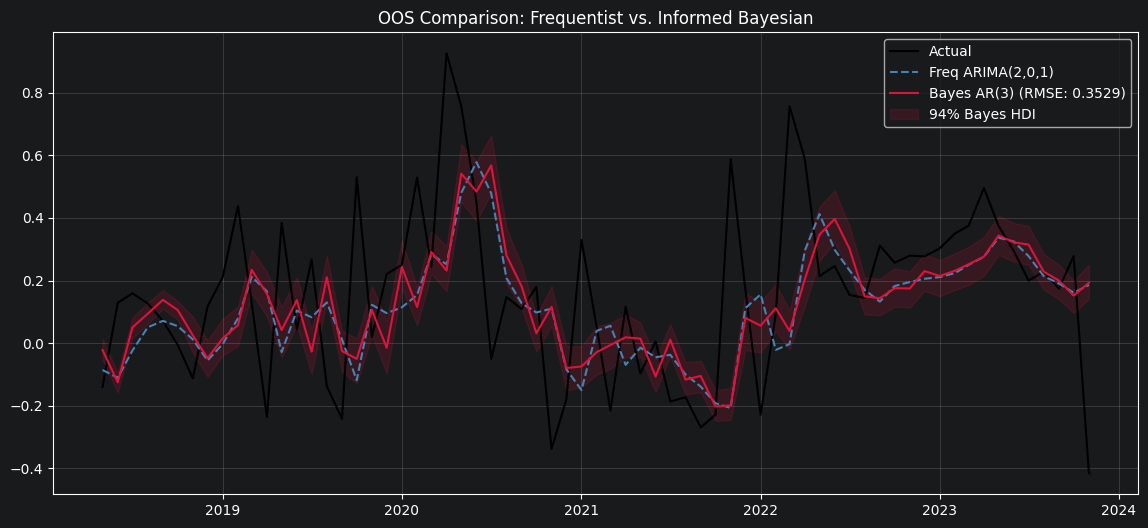

In [18]:
plt.figure(figsize=(14, 6))

# Plot actuals
plt.plot(y_test_ar.index, y_test_ar.values, color="black", label="Actual", linewidth=1.5)

# Plot Freq Forecast
plt.plot(y_test_arima.index, arima_201_forecast, color="steelblue",
         linestyle="--", label="Freq ARIMA(2,0,1)")

# Plot Bayes Forecast
plt.plot(y_test_ar.index, ar3_bayes_ew_forecast, color="crimson",
         label=f"Bayes AR(3) (RMSE: {df_cmp.loc['Bayes AR(3)', 'RMSE']:.4f})")

# Bayesian Uncertainty (HDI)
# Use the 'ew_hdi_lo' and 'ew_hdi_hi' calculated during your EW loop
plt.fill_between(y_test_ar.index, ew_hdi_lo, ew_hdi_hi, color="crimson", alpha=0.15, label="94% Bayes HDI")

plt.title("OOS Comparison: Frequentist vs. Informed Bayesian")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()